In [1]:
print("Day 6 Start")

Day 6 Start


In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

raw = yf.download ("SPY", start = "2025-01-01", end = "2026-01-01")
data = raw.droplevel("Ticker", axis = 1)
data['daily_return'] = data['Close'].pct_change()

print(data['daily_return'].describe())

[*********************100%***********************]  1 of 1 completed

count    249.000000
mean       0.000740
std        0.012299
min       -0.058543
25%       -0.003564
50%        0.001376
75%        0.005761
max        0.105019
Name: daily_return, dtype: float64


In [3]:
VaR_95 = data['daily_return'].quantile(0.05)
VaR_99 = data['daily_return'].quantile(0.01)

print(f"95% VaR: {VaR_95:.2%}")
print(f"99% VaR: {VaR_99:.2%}")

95% VaR: -1.65%
99% VaR: -3.58%


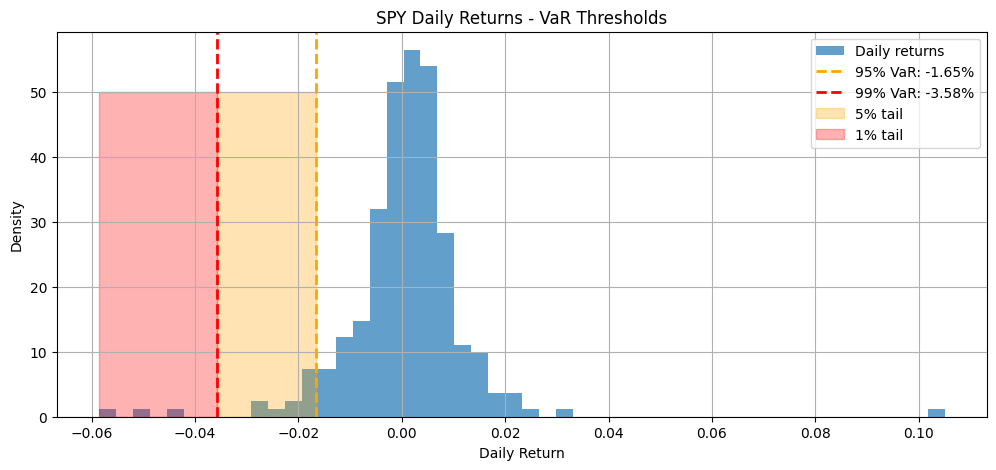

In [4]:
fig, ax = plt.subplots(figsize=(12,5))
data['daily_return'].hist(bins=50, ax=ax, density=True,
                          alpha=0.7, label='Daily returns')

ax.axvline(VaR_95, color='orange', linewidth=2,
           linestyle='--', label=f'95% VaR: {VaR_95:.2%}')

ax.axvline(VaR_99, color='red', linewidth=2,
           linestyle='--', label=f'99% VaR: {VaR_99:.2%}')

ax.fill_betweenx([0, 50], VaR_99, VaR_95,
                 alpha=0.3, color='orange', label='5% tail')
ax.fill_betweenx([0,50], data['daily_return'].min(), VaR_99,
                 alpha=0.3, color='red', label='1% tail')

plt.title("SPY Daily Returns - VaR Thresholds")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
#data [Filter] - Python feature
CVaR_95 = data['daily_return'][data['daily_return'] <= VaR_95].mean()
CVaR_99 = data['daily_return'][data['daily_return'] <= VaR_99].mean()

print(f"95% CVaR: {CVaR_95:.2%}")
print(f"99% CVaR: {CVaR_99:.2%}")

95% CVaR: -2.75%
99% CVaR: -5.05%
